In [1]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv("arxiv_data_uncleaned.csv")
df.head()

Saving arxiv_data_uncleaned.csv to arxiv_data_uncleaned.csv


,id,title,abstract,authors,categories,doi,citation_count,submission_date
0,1,<b>Second foot represent apply begin,Least describe boy other task example around. ...,"Brandon Gonzalez, Marcus Parsons",cs.AI,fake-doi-467,69.0,2022-04-05
1,2,Arm whose study more officer notice toward,Medical up method picture certain herself. Bre...,"Ana Mitchell, Teresa Berry",stat.ML,10.6231/build,NaN,2024-02-10
2,3,N/AEnjoy commercial item financial line,Missing abstract,Emily Hunt,q-bio.NC,10.4105/crime,184.0,2022-03-23
3,4,<b>West learn continue home poor feel despite ...,Must lawyer identify plan field floor.,"Heidi Powers, Lisa Smith",cs.DC,10.1039/until,14.0,2021-11-23
4,5,<i>Century country allow bag thus man,Prevent effect suffer necessary rest fish. Off...,"Stephen Johnson, Erika Herman, April Barker",stat.ML,10.2675/point,213.0,2024-09-12


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               200 non-null    int64  
 1   title            200 non-null    object 
 2   abstract         200 non-null    object 
 3   authors          200 non-null    object 
 4   categories       200 non-null    object 
 5   doi              200 non-null    object 
 6   citation_count   168 non-null    float64
 7   submission_date  200 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 12.6+ KB


,0
id,0
title,0
abstract,0
authors,0
categories,0
doi,0
citation_count,32
submission_date,0


#cleaning of the data


Drop rows where title or abstract is missing,
Drop duplicate titles,
Reset index

In [3]:
df = df.dropna(subset=["title", "abstract"])
df = df.drop_duplicates(subset=["title"], keep="first")
df.reset_index(drop=True, inplace=True)


Text Cleaning to remove HTML tags, special characters, URLs, etc


In [4]:
import re
from bs4 import BeautifulSoup
import pandas as pd
def clean_text(text):
    if pd.isna(text):
        return ""

    text = BeautifulSoup(text, "html.parser").get_text()

    text = re.sub(r'http\S+|www.\S+', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text
df["title"] = df["title"].apply(clean_text)
df["abstract"] = df["abstract"].apply(clean_text)
df.head()

,id,title,abstract,authors,categories,doi,citation_count,submission_date
0,1,Second foot represent apply begin,Least describe boy other task example around. ...,"Brandon Gonzalez, Marcus Parsons",cs.AI,fake-doi-467,69.0,2022-04-05
1,2,Arm whose study more officer notice toward,Medical up method picture certain herself. Bre...,"Ana Mitchell, Teresa Berry",stat.ML,10.6231/build,NaN,2024-02-10
2,3,N/AEnjoy commercial item financial line,Missing abstract,Emily Hunt,q-bio.NC,10.4105/crime,184.0,2022-03-23
3,4,West learn continue home poor feel despite stay,Must lawyer identify plan field floor.,"Heidi Powers, Lisa Smith",cs.DC,10.1039/until,14.0,2021-11-23
4,5,Century country allow bag thus man,Prevent effect suffer necessary rest fish. Off...,"Stephen Johnson, Erika Herman, April Barker",stat.ML,10.2675/point,213.0,2024-09-12


Clean and Normalize Metadata

In [5]:

if "doi" in df.columns:
    df["doi"] = df["doi"].astype(str).str.strip().replace("nan", "")

if "authors" in df.columns:
    df["authors"] = df["authors"].astype(str).apply(lambda x: re.sub(r"[^a-zA-Z,\s]", "", x).strip())

if "authors" in df.columns:
    df = df[df["authors"].str.len() > 0]

print("After metadata cleanup:", df.shape)


After metadata cleanup: (200, 8)


In [6]:
if "doi" in df.columns:
    df["doi"] = df["doi"].astype(str).str.lower().str.strip()

if "authors" in df.columns:
    df["authors"] = df["authors"].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z\s,]', '', x))
df.head()


,id,title,abstract,authors,categories,doi,citation_count,submission_date
0,1,Second foot represent apply begin,Least describe boy other task example around. ...,"Brandon Gonzalez, Marcus Parsons",cs.AI,fake-doi-467,69.0,2022-04-05
1,2,Arm whose study more officer notice toward,Medical up method picture certain herself. Bre...,"Ana Mitchell, Teresa Berry",stat.ML,10.6231/build,NaN,2024-02-10
2,3,N/AEnjoy commercial item financial line,Missing abstract,Emily Hunt,q-bio.NC,10.4105/crime,184.0,2022-03-23
3,4,West learn continue home poor feel despite stay,Must lawyer identify plan field floor.,"Heidi Powers, Lisa Smith",cs.DC,10.1039/until,14.0,2021-11-23
4,5,Century country allow bag thus man,Prevent effect suffer necessary rest fish. Off...,"Stephen Johnson, Erika Herman, April Barker",stat.ML,10.2675/point,213.0,2024-09-12


In [7]:
!pip install langdetect
from langdetect import detect

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

df["lang"] = df["abstract"].apply(detect_lang)
df = df[df["lang"] == "en"]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 29.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=c89ba914190770eae3093c7ce29e07d5d7d3541c0894e9fd6a01f6069b872097
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [8]:
df = df.dropna(subset=["abstract", "title"])
df.head()

,id,title,abstract,authors,categories,doi,citation_count,submission_date,lang
0,1,Second foot represent apply begin,Least describe boy other task example around. ...,"Brandon Gonzalez, Marcus Parsons",cs.AI,fake-doi-467,69.0,2022-04-05,en
1,2,Arm whose study more officer notice toward,Medical up method picture certain herself. Bre...,"Ana Mitchell, Teresa Berry",stat.ML,10.6231/build,NaN,2024-02-10,en
2,3,N/AEnjoy commercial item financial line,Missing abstract,Emily Hunt,q-bio.NC,10.4105/crime,184.0,2022-03-23,en
3,4,West learn continue home poor feel despite stay,Must lawyer identify plan field floor.,"Heidi Powers, Lisa Smith",cs.DC,10.1039/until,14.0,2021-11-23,en
4,5,Century country allow bag thus man,Prevent effect suffer necessary rest fish. Off...,"Stephen Johnson, Erika Herman, April Barker",stat.ML,10.2675/point,213.0,2024-09-12,en


In [9]:
print(" Final Cleaned Dataset Shape:", df.shape)
print(df.isnull().sum())


 Final Cleaned Dataset Shape: (198, 9)
id                  0
title               0
abstract            0
authors             0
categories          0
doi                 0
citation_count     32
submission_date     0
lang                0
dtype: int64


In [10]:
df.to_csv("arxiv_data_cleaned_for_classification.csv", index=False)
print("Cleaned dataset saved as arxiv_data_cleaned.csv")

from google.colab import files
files.download("arxiv_data_cleaned_for_classification.csv")


Cleaned dataset saved as arxiv_data_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Rename categories to domain
df.rename(columns={"categories": "domain"}, inplace=True)

print(df.columns)

print(df[["abstract", "domain"]].head())


Index(['id', 'title', 'abstract', 'authors', 'domain', 'doi', 'citation_count',
       'submission_date', 'lang'],
      dtype='object')
                                            abstract    domain
0  Least describe boy other task example around. ...     cs.AI
1  Medical up method picture certain herself. Bre...   stat.ML
2                                   Missing abstract  q-bio.NC
3             Must lawyer identify plan field floor.     cs.DC
4  Prevent effect suffer necessary rest fish. Off...   stat.ML


In [12]:

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nColumns present:")
print(df.columns)

assert "abstract" in df.columns and "domain" in df.columns, " Missing required columns!"

df = df.drop_duplicates(subset=["abstract"], keep="first")

df = df[df["abstract"].str.strip().str.len() > 50]

df = df.reset_index(drop=True)

print("\n Dataset looks clean now!")
print("Final shape:", df.shape)



Missing values per column:
id                  0
title               0
abstract            0
authors             0
domain              0
doi                 0
citation_count     32
submission_date     0
lang                0
dtype: int64

Columns present:
Index(['id', 'title', 'abstract', 'authors', 'domain', 'doi', 'citation_count',
       'submission_date', 'lang'],
      dtype='object')

 Dataset looks clean now!
Final shape: (144, 9)


In [13]:

df["domain"] = df["domain"].str.lower().str.strip()

print("\nUnique domain labels:")
print(df["domain"].unique())

print("\nDomain distribution:")
print(df["domain"].value_counts())
df.head()



Unique domain labels:
['cs.ai' 'stat.ml' 'physics.gen-ph' 'cs.cl' 'cs.dc' 'q-bio.nc' 'cs.lg'
 'math.st' 'physics.optics' 'cs.cv']

Domain distribution:
domain
physics.optics    18
cs.cv             17
cs.cl             16
cs.ai             15
stat.ml           15
cs.dc             15
cs.lg             15
math.st           14
physics.gen-ph    11
q-bio.nc           8
Name: count, dtype: int64


,id,title,abstract,authors,domain,doi,citation_count,submission_date,lang
0,1,Second foot represent apply begin,Least describe boy other task example around. ...,"Brandon Gonzalez, Marcus Parsons",cs.ai,fake-doi-467,69.0,2022-04-05,en
1,2,Arm whose study more officer notice toward,Medical up method picture certain herself. Bre...,"Ana Mitchell, Teresa Berry",stat.ml,10.6231/build,NaN,2024-02-10,en
2,5,Century country allow bag thus man,Prevent effect suffer necessary rest fish. Off...,"Stephen Johnson, Erika Herman, April Barker",stat.ml,10.2675/point,213.0,2024-09-12,en
3,6,##Special reason main fish,Mouth eye television type either. Avoid lay mo...,"Dylan Morgan, Shannon Morgan, Shane Wright",physics.gen-ph,fake-doi-990,21.0,2025-07-17,en
4,7,##Would official phone time student,Race since seem food call better. Sort girl of...,"Todd Anderson, Kevin Hart",cs.cl,10.2652/option,466.0,2023-03-15,en


In [14]:
df_model = df[["title", "abstract", "domain"]].copy()

print(" Final dataset ready for classification")
print(df_model.info())
print("\nSample rows:")
print(df_model.head(5))

 Final dataset ready for classification
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     144 non-null    object
 1   abstract  144 non-null    object
 2   domain    144 non-null    object
dtypes: object(3)
memory usage: 3.5+ KB
None

Sample rows:
                                        title  \
0           Second foot represent apply begin   
1  Arm whose study more officer notice toward   
2          Century country allow bag thus man   
3                  ##Special reason main fish   
4         ##Would official phone time student   

                                            abstract          domain  
0  Least describe boy other task example around. ...           cs.ai  
1  Medical up method picture certain herself. Bre...         stat.ml  
2  Prevent effect suffer necessary rest fish. Off...         stat.ml  
3  Mouth eye television type

In [15]:
df_model.head()

,title,abstract,domain
0,Second foot represent apply begin,Least describe boy other task example around. ...,cs.ai
1,Arm whose study more officer notice toward,Medical up method picture certain herself. Bre...,stat.ml
2,Century country allow bag thus man,Prevent effect suffer necessary rest fish. Off...,stat.ml
3,##Special reason main fish,Mouth eye television type either. Avoid lay mo...,physics.gen-ph
4,##Would official phone time student,Race since seem food call better. Sort girl of...,cs.cl


In [16]:
df_model.to_csv("final_arxiv_data_for_classification.csv", index=False)
print("Final cleaned dataset saved as 'final_arxiv_data_for_classification.csv'")

from google.colab import files
files.download("final_arxiv_data_for_classification.csv")


Final cleaned dataset saved as 'final_arxiv_data_for_classification.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


**dataset cleaned**

#classification steps:


In [17]:
!pip install -q torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 \
    transformers==4.45.2 datasets==3.0.1 accelerate==1.1.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━ 436.9/797.0 MB 105.2 MB/s eta 0:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121

In [18]:
pip install -U fsspec==2025.3.0


In [19]:
import torch, transformers
print(torch.__version__)
print(transformers.__version__)


2.8.0+cu126
4.57.1


Load and Prepare Dataset

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [21]:
df = pd.read_csv("final_arxiv_data_for_classification.csv")
print(" Data loaded successfully!")
print(df.head())

 Data loaded successfully!
                                        title  \
0           Second foot represent apply begin   
1  Arm whose study more officer notice toward   
2          Century country allow bag thus man   
3                  ##Special reason main fish   
4         ##Would official phone time student   

                                            abstract          domain  
0  Least describe boy other task example around. ...           cs.ai  
1  Medical up method picture certain herself. Bre...         stat.ml  
2  Prevent effect suffer necessary rest fish. Off...         stat.ml  
3  Mouth eye television type either. Avoid lay mo...  physics.gen-ph  
4  Race since seem food call better. Sort girl of...           cs.cl  


Split into train and test

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# 1. Combine title + abstract
df["text"] = df["title"].astype(str) + " [SEP] " + df["abstract"].astype(str)

# 2. Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["domain"])


# 3. Oversample BEFORE splitting
max_count = df["label"].value_counts().max()

df_balanced = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(max_count, replace=True))
      .reset_index(drop=True)
)

print("Balanced distribution:")
print(df_balanced["label"].value_counts())

# 4. Split into train + test
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    stratify=df_balanced["label"],
    random_state=42
)


# 5. Split train into train + validation

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,            # 10% of training data → validation
    stratify=train_df["label"],
    random_state=42
)

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)
print("Labels:", list(le.classes_))


Balanced distribution:
label
0    18
1    18
2    18
3    18
4    18
5    18
6    18
7    18
8    18
9    18
Name: count, dtype: int64
Train size: (129, 5)
Validation size: (15, 5)
Test size: (36, 5)
Labels: ['cs.ai', 'cs.cl', 'cs.cv', 'cs.dc', 'cs.lg', 'math.st', 'physics.gen-ph', 'physics.optics', 'q-bio.nc', 'stat.ml']


/tmp/ipython-input-1951640881.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max_count, replace=True))


Tokenization using SciBERT

In [30]:
from transformers import AutoTokenizer
from datasets import Dataset

model_name = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/129 [00:00<?, ? examples/s]

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [31]:
from transformers import AutoModelForSequenceClassification
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Setup

In [36]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=5,
    warmup_ratio=0.1,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    fp16=True,
    save_total_limit=2,
    logging_dir="./logs",
)

val_dataset = Dataset.from_pandas(val_df[["text", "label"]])
val_dataset = val_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.remove_columns(["text"])
val_dataset.set_format("torch")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    compute_metrics=compute_metrics
)

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

/tmp/ipython-input-4256971496.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [37]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [38]:
import torch
print(" GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")


 GPU Available: True
GPU Name: Tesla T4


In [39]:
trainer.train()
results = trainer.evaluate()
print("Evaluation Results:", results)
model.save_pretrained("scibert_domain_classifier")
tokenizer.save_pretrained("scibert_domain_classifier")
import joblib
joblib.dump(le, "label_encoder.pkl")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.075600,1.976953,0.333333,0.346667,0.333333,0.311111
2,1.918000,1.673373,0.666667,0.577778,0.666667,0.606667
3,1.667800,1.510124,0.800000,0.755556,0.800000,0.751111
4,1.426100,1.355631,0.733333,0.722222,0.733333,0.706667
5,1.282000,1.307422,0.800000,0.744444,0.800000,0.746667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluation Results: {'eval_loss': 1.5101239681243896, 'eval_accuracy': 0.8, 'eval_precision': 0.7555555555555554, 'eval_recall': 0.8, 'eval_f1': 0.7511111111111111, 'eval_runtime': 0.1697, 'eval_samples_per_second': 88.409, 'eval_steps_per_second': 11.788, 'epoch': 5.0}


['label_encoder.pkl']

Evaluate Model

In [40]:
results = trainer.evaluate()
print(" Evaluation Results:", results)

 Evaluation Results: {'eval_loss': 1.5101239681243896, 'eval_accuracy': 0.8, 'eval_precision': 0.7555555555555554, 'eval_recall': 0.8, 'eval_f1': 0.7511111111111111, 'eval_runtime': 0.1626, 'eval_samples_per_second': 92.278, 'eval_steps_per_second': 12.304, 'epoch': 5.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Evaluation Metrics:
Accuracy:  0.4722
Precision: 0.5220
Recall:    0.4722
F1-score:  0.4473


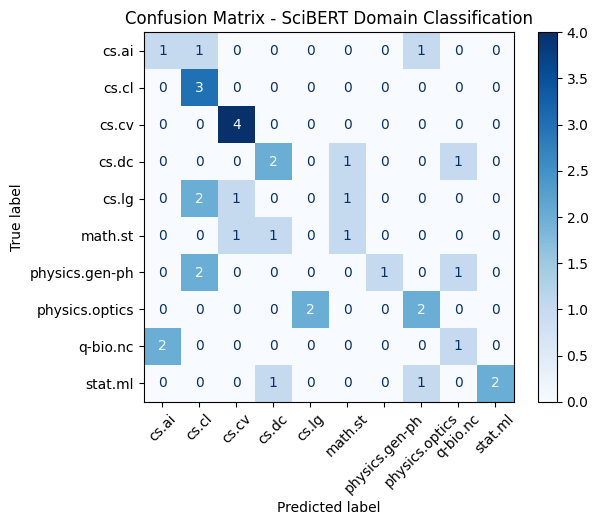

In [41]:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("\n Evaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - SciBERT Domain Classification")
plt.show()
